# Predicting Differentiated Thyroid Cancer Recurrence using Machine Learning #

### Load and exploring dataset ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Users\Administrator\Downloads\differentiated+thyroid+cancer+recurrence\Thyroid_Diff.csv')

In [3]:
print(df.shape)
df.info()

(383, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-

##  EDA  ##

In [4]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [6]:
df.dtypes

Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                object
dtype: object

### Target Distribution ###

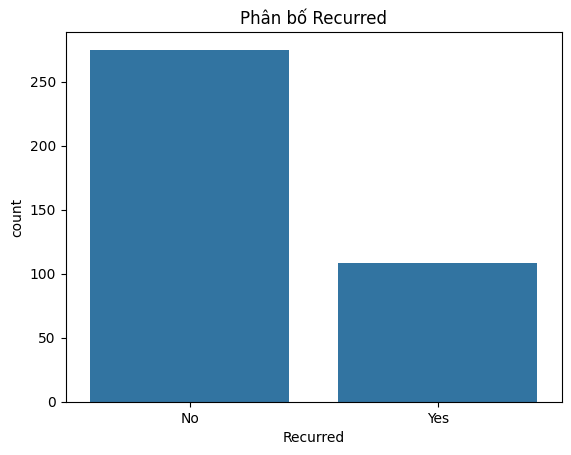

In [7]:
df['Recurred'].value_counts()
df['Recurred'].value_counts(normalize=True)

sns.countplot(data=df, x = 'Recurred')
plt.title('Phân bố Recurred')
plt.show()

### Age Distribution ###

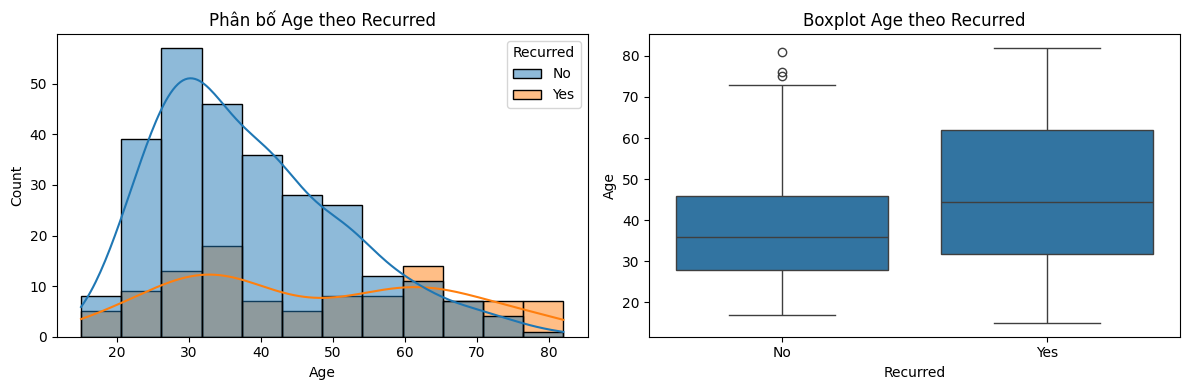

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='Age', hue='Recurred', kde=True, ax = axes[0])
axes[0].set_title('Phân bố Age theo Recurred')

sns.boxplot(data=df, x='Recurred', y='Age', ax = axes[1])
axes[1].set_title('Boxplot Age theo Recurred')

plt.tight_layout()
plt.show()

### Countplot categorical ###

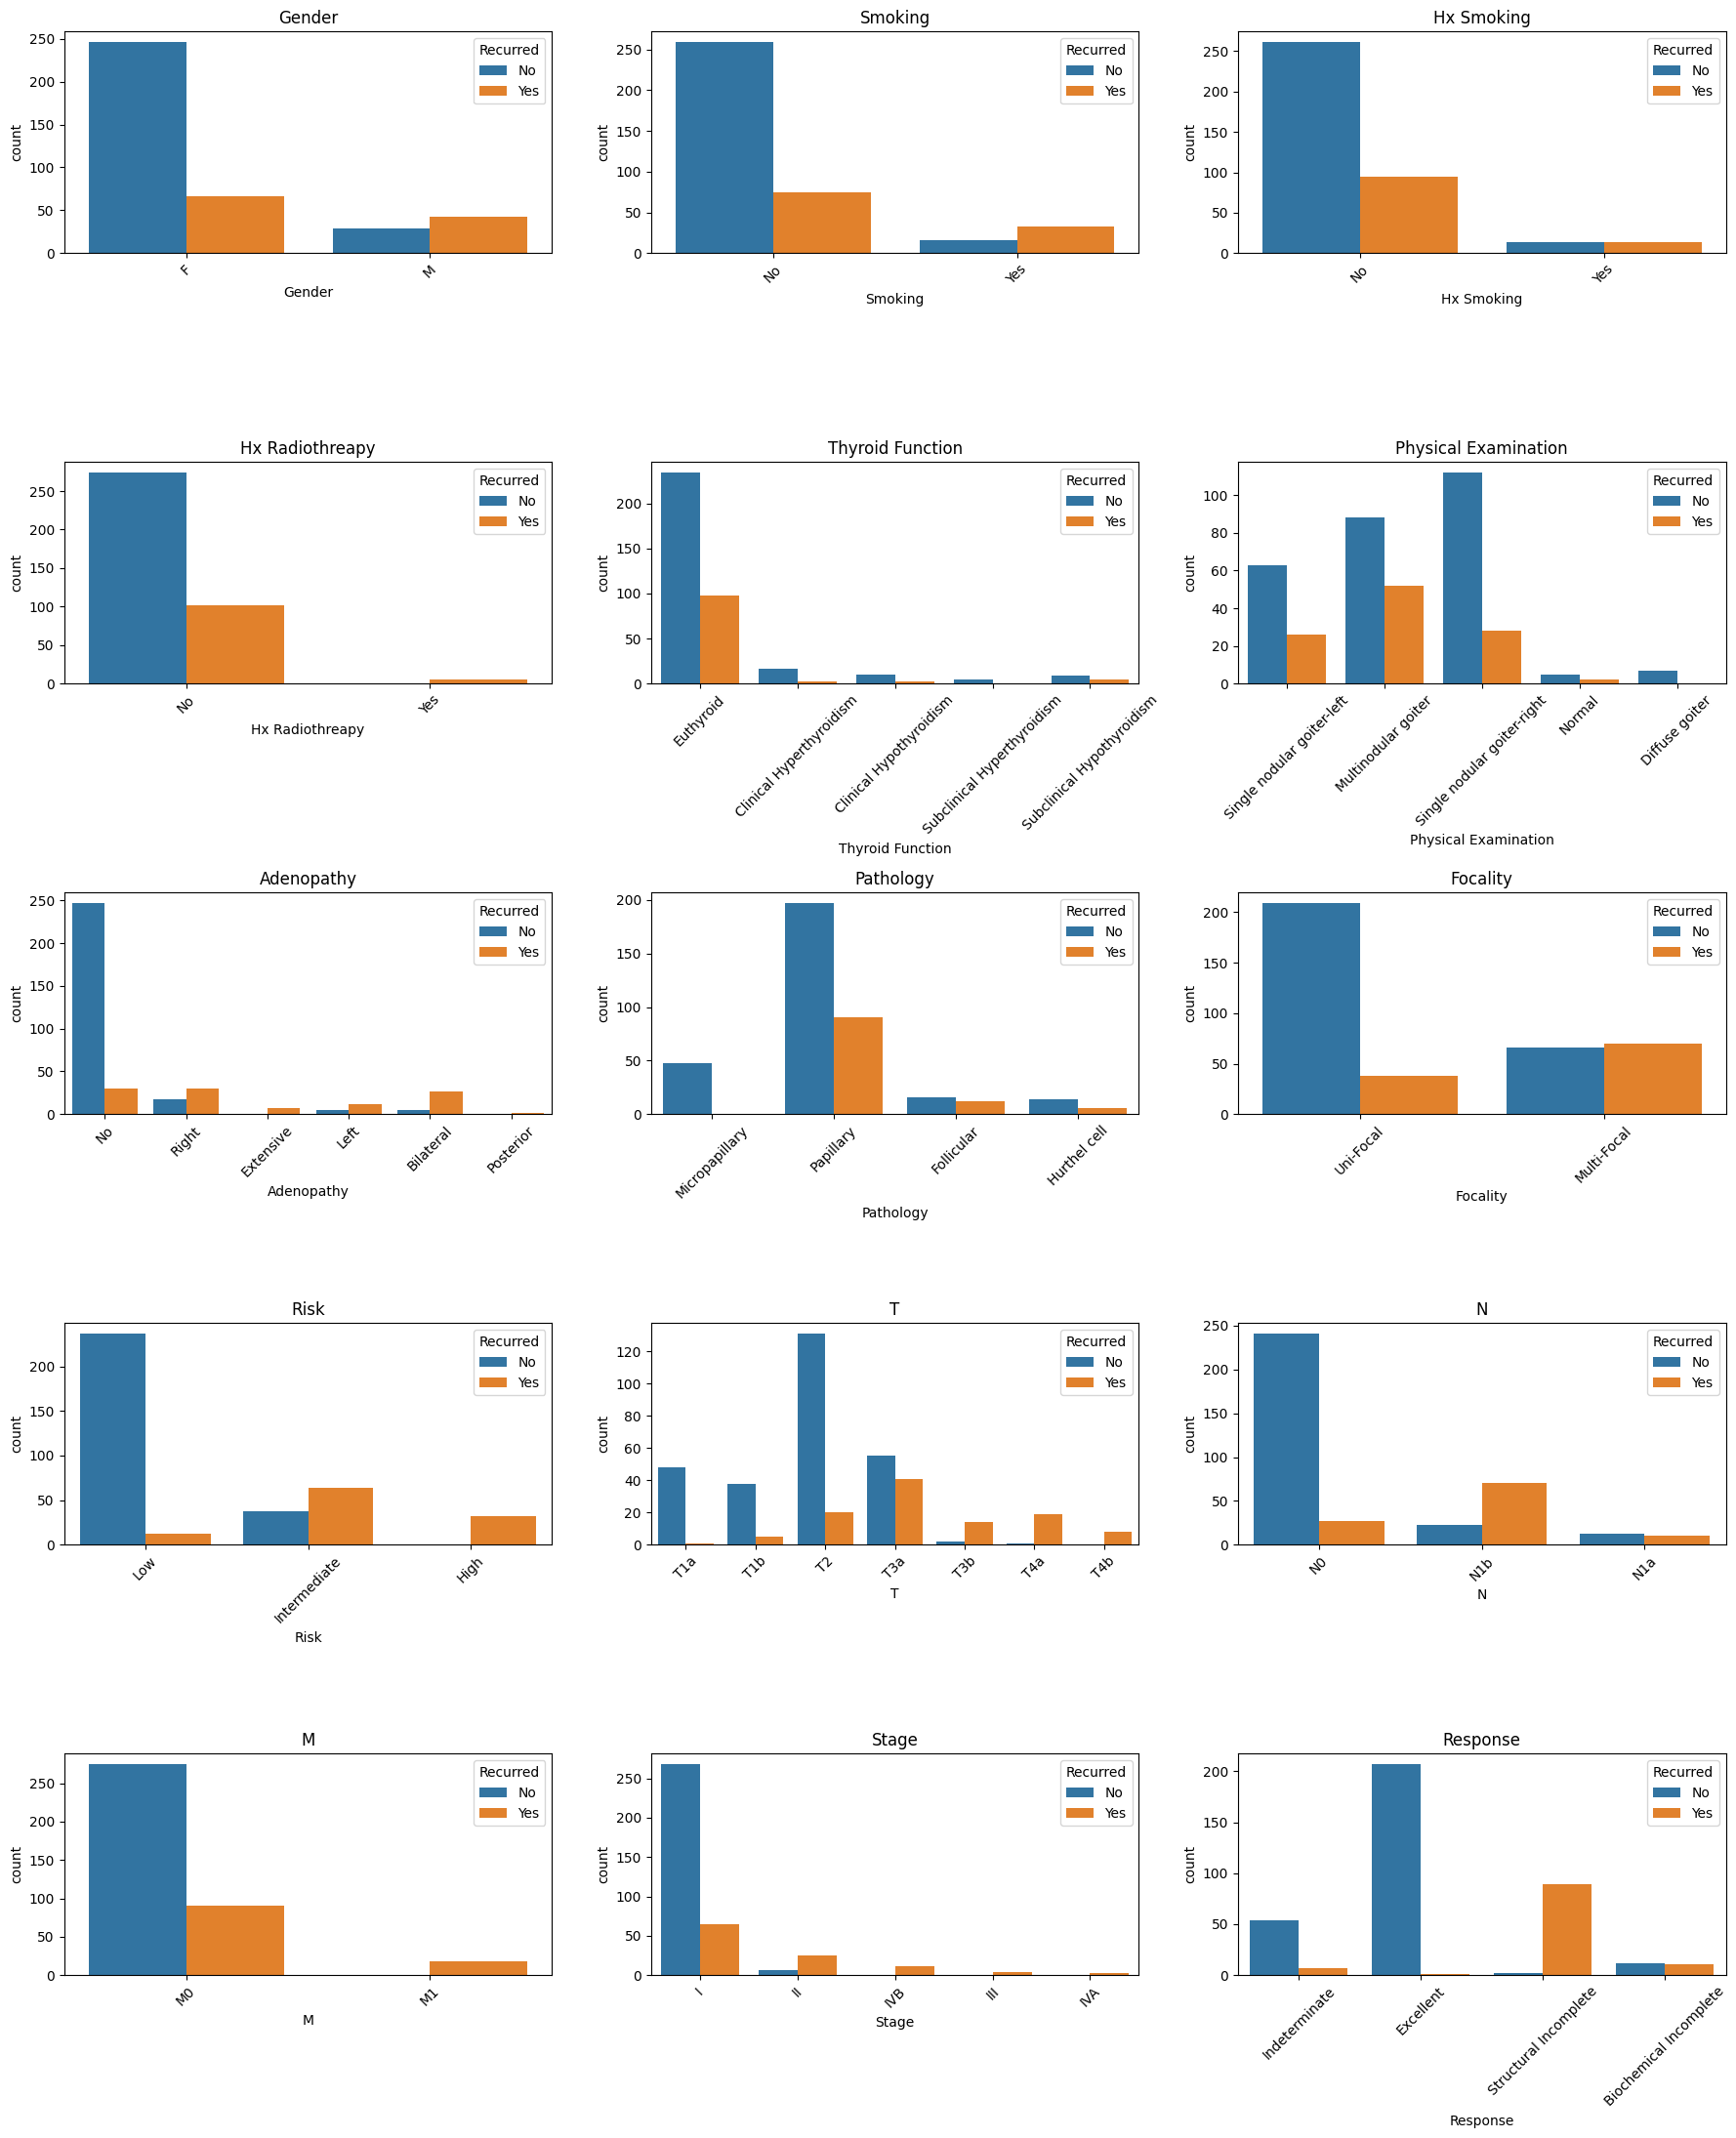

In [9]:
categorical_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                     'Thyroid Function', 'Physical Examination', 'Adenopathy',
                     'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Recurred', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
F    312
M     71
Name: count, dtype: int64

Smoking:
Smoking
No     334
Yes     49
Name: count, dtype: int64

Hx Smoking:
Hx Smoking
No     355
Yes     28
Name: count, dtype: int64

Hx Radiothreapy:
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64

Thyroid Function:
Thyroid Function
Euthyroid                      332
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64

Physical Examination:
Physical Examination
Multinodular goiter            140
Single nodular goiter-right    140
Single nodular goiter-left      89
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64

Adenopathy:
Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, dtype: int64

Pathology:
Pathology
Papillary         287
Micropapillary     48
Follicular         2

In [11]:
pd.crosstab(df['T'], df['Stage'])
pd.crosstab(df['N'], df['Stage'])
pd.crosstab(df['M'], df['Stage'])

Stage,I,II,III,IVA,IVB
M,,,,,
M0,332,25,4,3,1
M1,1,7,0,0,10


### Check outlier ###

In [12]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Age'] < Q1 - 1.5*IQR) | (df['Age'] > Q3 - 1.5*IQR)]
print(f'Số outlier: {len(outliers)}')

Số outlier: 378


### Percentage ###

In [13]:
pd.crosstab(df['Risk'], df['Recurred'], normalize='index')

Recurred,No,Yes
Risk,,
High,0.000000,1.000000
Intermediate,0.372549,0.627451
Low,0.951807,0.048193


In [17]:
from ydata_profiling import ProfileReport

df = pd.read_csv(r"C:\Users\Administrator\Downloads\differentiated+thyroid+cancer+recurrence\Thyroid_Diff.csv")

profile = ProfileReport(
    df,
    title="Thyroid Cancer Report",
    explorative=True
)

profile.to_file('Thyroid_Cancer_Profile_Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 100.59it/s]A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Kết luận từ EDA

- Risk = High có tỷ lệ tái phát 85% (so với 12% ở Risk = Low) → biến phân biệt mạnh nhất
- T, N, M, Stage có tương quan cao (Stage IVB luôn đi kèm M1) → cân nhắc giữ Stage, bỏ M để tránh đa cộng tuyến
- Adenopathy = Posterior chỉ có 3 mẫu → gộp vào nhóm "Other"
- Age không khác biệt rõ giữa 2 nhóm Recurred → có thể không phải biến quan trọng
- Target lệch 72%/28% → áp dụng SMOTE hoặc class_weight khi train